In [31]:
import sys
sys.path.append('..')
import torch
from encoder import FMEncoder, compute_spectrogram_cqt
from fm_ddsp import fm_renderer, make_mod_matrix
from nnAudio.features import CQT2010v2
import soundfile as sf
import json
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np
import os

%load_ext autoreload
%autoreload 2

def get_peaks(spec, cqt_transform, threshold_db=-40):
    magnitudes = spec.detach().numpy()
    max_mag = magnitudes.max()
    threshold_linear = max_mag * 10**(threshold_db/20)
    peaks, _ = find_peaks(magnitudes, height=threshold_linear, distance=5)
    
    # convert bin index to frequency
    # fmin defaults to 32.7Hz (C1), bins are logarithmically spaced
    fmin = 32.7
    freqs = fmin * 2 ** (peaks / bins_per_octave)
    
    return peaks, freqs, magnitudes[peaks]

def make_fundamental_weight(n_bins, fundamental_bin, bins_per_octave, suppression = 0.1, width = 2.0):
    bins = torch.arange(n_bins, dtype=torch.float32)
    gaussian = torch.exp(-0.5 * ((bins - fundamental_bin) / (width*bins_per_octave / 12)) ** 2)
    freq_weights = 1.0 - (1.0 - suppression) * gaussian
    return freq_weights

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Low pass filter created, time used = 0.0013 seconds
num_octave =  7
No early downsampling is required, downsample_factor =  1
Early downsampling filter created,                         time used = 0.0000 seconds
CQT kernels created, time used = 0.0020 seconds
Test Parameters: {'f0': 440.0, 'algorithm': 'algo_2', 'mod_values': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0], 'ratios': [1.0, 1.0, 0.5, 1.0], 'levels': [0.0, 0.0, 0.10133033990859985, 1.0], 'carrier_weights': [0.0, 0.0, 0.0, 1.0]}
Saved output.wav
Predicted ratios: tensor([[0.9850, 0.9315, 1.4043, 0.9948]])
Predicted levels: tensor([[0.7387, 0.9713, 0.4297, 0.4885]])
Predicted mod_values: tensor([[0.0697, 0.5126, 0.9919, 0.9694, 0.5159, 0.5783, 0.4922]])


C:\Users\Marcus\AppData\Local\Temp\ipykernel_31512\3803969620.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  spec = torch.tensor(spec).float().to(device)


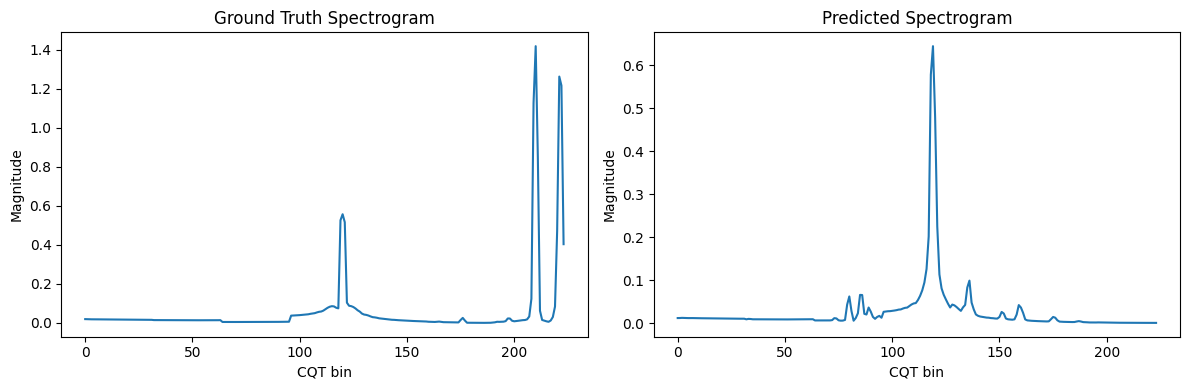

GT f0: 440.0Hz, used f0: 440.0Hz
GT ratios:    [1.0, 1.0, 8.0, 1.0]
Pred ratios:  [0.9849933385848999, 0.9315217137336731, 1.4042713642120361, 0.9947823882102966]
GT levels:    [0.0, 0.0, 0.9806274771690369, 1.0]
Pred levels:  [0.7387188076972961, 0.9712618589401245, 0.429749459028244, 0.4885292947292328]
           Ground Truth                          Predicted             
      Freq (Hz)        Mag (dB)         Freq (Hz)        Mag (dB)
----------------------------------------------------------------------
          440.0            -8.1             206.1           -19.8
         3090.7             0.0             430.5             0.0
         3922.3            -1.0             622.2           -16.3


In [40]:
# setup
device = torch.device('cpu')
Fs = 16000
duration = 1.0
hop_size = 512
bins_per_octave = 32
n_octaves = 7
n_bins = bins_per_octave*n_octaves
fmin = 32.7 #default for CQT2010v2

# load encoder
save_dir_pc = "B:\\TrainingData\\stage1"
epoch = 9
example_num = '00090'
encoder_pt = os.path.join(save_dir_pc,"output",f"encoder_epoch_{epoch}.pt")
encoder = FMEncoder(n_bins=224).to(device)
encoder.load_state_dict(torch.load(encoder_pt,
                                   map_location = device))
encoder.eval()

cqt_transform = CQT2010v2(sr=Fs,
                          hop_length = hop_size,
                          n_bins = n_bins,
                          bins_per_octave = bins_per_octave).to(device)

# load a target audio from the dataset
spec = torch.load(os.path.join(save_dir_pc,f'spec_{example_num}.pt'),weights_only=False)
spec = torch.tensor(spec).float().to(device)

with open(os.path.join(save_dir_pc,'params_00000.json')) as f:
    params = json.load(f)
    print(f"Test Parameters: {params}")

with torch.no_grad():
    predicted = encoder(spec.unsqueeze(0))

# render audio
f0 = params['f0']
# create frequency weights and reduce fundamental
freq_weights = torch.ones(n_bins)
fundamental_bin = int(bins_per_octave * np.log2(f0 / fmin))
freq_weights = make_fundamental_weight(n_bins, fundamental_bin, bins_per_octave, 
                                       suppression = .2, 
                                       width = 1.2)
mod_matrix = make_mod_matrix(predicted['mod_values'][0])
audio = fm_renderer(f0,
                    predicted['ratios'][0],
                    predicted['levels'][0],
                    mod_matrix,
                    predicted['carrier_weights'][0],
                    Fs, duration)

# save to wav
sf.write('output.wav', audio.detach().numpy(), Fs)
print("Saved output.wav")
print("Predicted ratios:", predicted['ratios'])
print("Predicted levels:", predicted['levels'])
print("Predicted mod_values:", predicted['mod_values'])

# load ground truth parameters
with open(os.path.join(save_dir_pc,f"params_{example_num}.json"), 'r') as f:
    gt_params = json.load(f)

# render ground truth audio
gt_mod_matrix = make_mod_matrix(torch.tensor(gt_params['mod_values']))
gt_audio = fm_renderer(
    gt_params['f0'],
    torch.tensor(gt_params['ratios']),
    torch.tensor(gt_params['levels']),
    gt_mod_matrix,
    torch.tensor(gt_params['carrier_weights']),
    Fs, duration
)

# save both
sf.write('output_predicted.wav', audio.detach().numpy(), Fs)
sf.write('output_groundtruth.wav', gt_audio.detach().numpy(), Fs)

# compute spectrogram of both
pred_spec = compute_spectrogram_cqt(audio.detach(), cqt_transform)*freq_weights
gt_spec = compute_spectrogram_cqt(gt_audio.detach(), cqt_transform)*freq_weights

# plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(gt_spec.numpy())
plt.title('Ground Truth Spectrogram')
plt.xlabel('CQT bin')
plt.ylabel('Magnitude')

plt.subplot(1, 2, 2)
plt.plot(pred_spec.detach().numpy())
plt.title('Predicted Spectrogram')
plt.xlabel('CQT bin')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()

# print parameter comparison
print(f"GT f0: {gt_params['f0']:.1f}Hz, used f0: {f0}Hz")
print(f"GT ratios:    {gt_params['ratios']}")
print(f"Pred ratios:  {predicted['ratios'][0].tolist()}")
print(f"GT levels:    {gt_params['levels']}")
print(f"Pred levels:  {predicted['levels'][0].tolist()}")

gt_peaks, gt_freqs, gt_mags = get_peaks(gt_spec, cqt_transform, threshold_db=-20)
pred_peaks, pred_freqs, pred_mags = get_peaks(pred_spec, cqt_transform, threshold_db=-20)

print(f"{'Ground Truth':^35} {'Predicted':^35}")
print(f"{'Freq (Hz)':>15} {'Mag (dB)':>15}   {'Freq (Hz)':>15} {'Mag (dB)':>15}")
print("-" * 70)

max_peaks = max(len(gt_peaks), len(pred_peaks))
for i in range(max_peaks):
    gt_str = f"{gt_freqs[i]:>15.1f} {20*np.log10(gt_mags[i]/gt_mags.max()):>15.1f}" if i < len(gt_peaks) else f"{'---':>15} {'---':>15}"
    pred_str = f"{pred_freqs[i]:>15.1f} {20*np.log10(pred_mags[i]/pred_mags.max()):>15.1f}" if i < len(pred_peaks) else f"{'---':>15} {'---':>15}"
    print(f"{gt_str}   {pred_str}")
                          